# Stochastic reservoir-to-market optimization

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/reservoir/stochastic_reservoir_to_market_optimization.ipynb)

**OPM Flow forecasts + ERT ensembles + NeqSim Java `master` wells/SURF/process +
Pyomo decisions**

This long-form study connects subsurface uncertainty to market value without breaking
realization identity. Each scenario is one internally consistent chain: ERT sample →
OPM Flow forecast → NeqSim well/SURF/process response → prices, uptime, and costs →
Pyomo recourse. P10/P50/P90 are ranked *complete scenario outcomes*; they are never
assembled by mixing independent percentiles from different models.

The notebook is a teaching-scale field-development study. Its synthetic grid,
commercial assumptions, and prices are not an asset forecast.

## What the notebook demonstrates

1. Sample correlated technical and commercial uncertainty with ERT 23.0.1.
2. Run twelve real OPM Flow 2026.04 reservoir simulations.
3. Build well and subsea production-system response maps with the NeqSim Java JAR
   compiled from the current `master` commit.
4. Run three-phase separation, compression, and cooling in NeqSim.
5. Optimize well chokes, compressor configuration, third-party host holdback, and a
   non-anticipative upgrade year in Pyomo/HiGHS.
6. Quantify the stochastic solution, expected-value policy, perfect information,
   value of the stochastic solution (VSS), and expected value of perfect information
   (EVPI).
7. Export a scenario ledger that preserves every cross-model identity key.

## 1. Reproducible runtime

In Colab, the next cell installs the pinned Python tools and OPM Flow, clones NeqSim
Java `master`, and builds the JAR from source. In repository validation, environment
variables point to the same locally built components so no Python NeqSim wheel is
used. The resolved Git commit and class code source are printed and later written to
the provenance manifest.

In [1]:
import os
import shutil
import subprocess
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
NEQSIM_SOURCE_REF = os.environ.get("NEQSIM_SOURCE_REF", "master")
os.environ.setdefault("NEQSIM_JVM_AUTOSTART", "false")
if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "ert==23.0.1",
            "opm==2026.4",
            "pyomo==6.9.3",
            "highspy==1.11.0",
            "jpype1==1.7.1",
            "pandas",
            "matplotlib",
            "scipy",
            "seaborn",
        ],
        check=True,
    )
    subprocess.run(
        ["sudo", "add-apt-repository", "-y", "ppa:opm/ppa"],
        check=True,
    )
    subprocess.run(["sudo", "apt-get", "update", "-qq"], check=True)
    subprocess.run(
        ["sudo", "apt-get", "install", "-y", "libopm-simulators-bin"],
        check=True,
    )
    source_root = Path("neqsim-java-master")
    if not source_root.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                NEQSIM_SOURCE_REF,
                "https://github.com/equinor/neqsim.git",
                str(source_root),
            ],
            check=True,
        )
    subprocess.run(
        ["./mvnw", "-q", "-DskipTests", "package"],
        cwd=source_root,
        check=True,
    )
else:
    source_root = Path(
        os.environ.get("NEQSIM_SOURCE_ROOT", "neqsim-java-master")
    )

jar_candidates = sorted((source_root / "target").glob("neqsim-*.jar"))
jar_candidates = [p for p in jar_candidates if "original" not in p.name]
if not jar_candidates:
    raise FileNotFoundError("Build NeqSim Java master before continuing.")
NEQSIM_JAR = jar_candidates[-1].resolve()
NEQSIM_COMMIT = subprocess.check_output(
    ["git", "rev-parse", "HEAD"], cwd=source_root, text=True
).strip()
FLOW_EXECUTABLE = os.environ.get(
    "OPM_FLOW_EXECUTABLE", shutil.which("flow") or "flow"
)
print(f"NeqSim source commit: {NEQSIM_COMMIT}")
print(f"NeqSim source-built JAR: {NEQSIM_JAR}")
print(f"OPM Flow executable: {FLOW_EXECUTABLE}")

NeqSim source commit: 5dc8b21b4535b4466820f88f520d69249d147757
NeqSim source-built JAR: /workspace/scratch/1bc38336988c/neqsim-colab/neqsim-java-master/target/neqsim-3.16.0.jar
OPM Flow executable: /workspace/scratch/1bc38336988c/neqsim-colab/.opm-root/usr/bin/flow


In [2]:
import json
import math
import platform
import tempfile
import time
import uuid
import warnings

import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyomo.environ as pyo
import scipy
import seaborn as sns
from IPython.display import display
from jpype import JClass
from opm.io import Parser
from opm.io.ecl import ESmry
from scipy.stats import norm

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 30)
np.set_printoptions(precision=3, suppress=True)

if not jpype.isJVMStarted():
    # Direct JPype startup replaces the Python wrapper's addClassPath route.
    jpype.startJVM(classpath=[str(NEQSIM_JAR)])

SystemSrkCPAstatoil = JClass(
    "neqsim.thermo.system.SystemSrkCPAstatoil"
)
Stream = JClass("neqsim.process.equipment.stream.Stream")
PipeBeggsAndBrills = JClass(
    "neqsim.process.equipment.pipeline.PipeBeggsAndBrills"
)
ThrottlingValve = JClass(
    "neqsim.process.equipment.valve.ThrottlingValve"
)
ThreePhaseSeparator = JClass(
    "neqsim.process.equipment.separator.ThreePhaseSeparator"
)
Compressor = JClass("neqsim.process.equipment.compressor.Compressor")
Cooler = JClass("neqsim.process.equipment.heatexchanger.Cooler")
ProcessSystem = JClass("neqsim.process.processmodel.ProcessSystem")

OUTPUT_ROOT = Path("stochastic_reservoir_market_outputs")
if OUTPUT_ROOT.exists():
    shutil.rmtree(OUTPUT_ROOT)
OUTPUT_ROOT.mkdir()
N_SCENARIOS = 12
YEARS = np.arange(1, 9)
WELLS = ["P1", "P2", "P3"]
DAYS_PER_YEAR = 365.25
DISCOUNT_RATE = 0.08
UPGRADE_CAPEX_NOK = 160.0e6
WELL_LIFT_COST_NOK_SM3 = {"P1": 5.0, "P2": 10.0, "P3": 18.0}
RNG_SEED = 72631

In [3]:
class_source = str(
    SystemSrkCPAstatoil.class_.getProtectionDomain()
    .getCodeSource()
    .getLocation()
)
versions = pd.DataFrame(
    {
        "component": [
            "NeqSim Java",
            "OPM Flow",
            "ERT",
            "Pyomo",
            "HiGHS",
            "Python",
        ],
        "version_or_identity": [
            NEQSIM_COMMIT,
            subprocess.check_output(
                [FLOW_EXECUTABLE, "--version"],
                text=True,
                env={
                    **os.environ,
                    "LD_LIBRARY_PATH": os.environ.get(
                        "OPM_FLOW_LIBRARY_PATH",
                        os.environ.get("LD_LIBRARY_PATH", ""),
                    ),
                    "OPAL_PREFIX": os.environ.get(
                        "OPM_FLOW_OPAL_PREFIX", "/usr"
                    ),
                },
            ).strip().splitlines()[-1],
            "23.0.1",
            pyo.__version__ if hasattr(pyo, "__version__") else "6.9.3",
            "1.11.0",
            platform.python_version(),
        ],
    }
)
display(versions)
print(f"Loaded NeqSim class code source: {class_source}")
assert str(NEQSIM_JAR) in class_source

Loaded NeqSim class code source: file:/workspace/scratch/1bc38336988c/neqsim-colab/neqsim-java-master/target/neqsim-3.16.0.jar


,component,version_or_identity
0,NeqSim Java,5dc8b21b4535b4466820f88f520d69249d147757
1,OPM Flow,flow 2026.04
2,ERT,23.0.1
3,Pyomo,6.9.3
4,HiGHS,1.11.0
5,Python,3.12.13


## 2. Stochastic architecture and information timing

The upgrade decision is made before uncertainty is revealed and must be identical in
all scenarios. Chokes, compressor train selection, and host holdback are yearly
recourse decisions. That is a two-stage model with multi-period recourse, not twelve
independent development plans.

$$\max_{x,u_s}\ -C^{\mathrm{up}}(x)+\sum_{s\in S}p_s\sum_{t\in T}
\frac{\Pi_{s,t}(u_{s,t};x)}{(1+r)^t}$$

subject to common upgrade starts $x_t$, scenario-year well and facility constraints,
and $\sum_t x_t\leq 1$. The upgrade active state is
$a_t=\sum_{\tau\leq t}x_\tau$.

### Identity rule

A scenario row carries `realization_id`, ERT seed and parameter vector, OPM deck and
run path, NeqSim source commit and response-map version, and market/economic inputs.
Joining downstream tables always includes `realization_id`. Petroleum P90/P50/P10 are
obtained by ranking full scenario NPVs (low/median/high), while retaining the complete
row and its lineage.

## 3. ERT ensemble and correlated uncertainty

ERT generates nine reproducible independent uniforms. A Cholesky transform converts
them to correlated standard normals, then bounded engineering variables. Keeping the
raw and transformed values makes the correlation model auditable. The small ensemble
is intentionally fast enough for Colab; a decision-grade study would use many more
realizations and convergence diagnostics.

In [4]:
parameter_names = [
    "POROSITY",
    "LOG_PERM",
    "VRR",
    "PI_MULT",
    "GOR",
    "OIL_PRICE",
    "GAS_PRICE",
    "AVAILABILITY",
    "HOST_RESERVE_FEE",
]
bounds = pd.DataFrame(
    {
        "parameter": parameter_names,
        "minimum": [0.18, 1.8, 0.75, 0.75, 110, 420, 1.8, 0.86, 38],
        "maximum": [0.30, 2.7, 1.15, 1.25, 220, 780, 4.2, 0.98, 82],
        "unit": [
            "fraction",
            "log10(mD)",
            "fraction",
            "multiplier",
            "Sm3/Sm3",
            "NOK/Sm3 oil",
            "NOK/Sm3 gas",
            "fraction",
            "NOK/Sm3-day-year",
        ],
    }
)
display(bounds)

,parameter,minimum,maximum,unit
0,POROSITY,0.18,0.30,fraction
1,LOG_PERM,1.80,2.70,log10(mD)
2,VRR,0.75,1.15,fraction
3,PI_MULT,0.75,1.25,multiplier
4,GOR,110.00,220.00,Sm3/Sm3
5,OIL_PRICE,420.00,780.00,NOK/Sm3 oil
6,GAS_PRICE,1.80,4.20,NOK/Sm3 gas
7,AVAILABILITY,0.86,0.98,fraction
8,HOST_RESERVE_FEE,38.00,82.00,NOK/Sm3-day-year


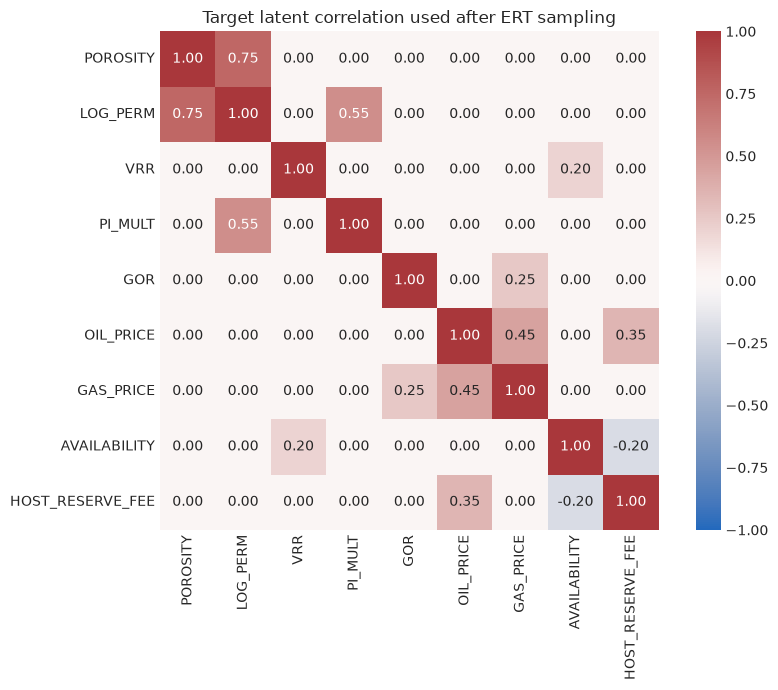

In [5]:
correlation = np.eye(len(parameter_names))
pairs = {
    ("POROSITY", "LOG_PERM"): 0.75,
    ("LOG_PERM", "PI_MULT"): 0.55,
    ("VRR", "AVAILABILITY"): 0.20,
    ("GOR", "GAS_PRICE"): 0.25,
    ("OIL_PRICE", "GAS_PRICE"): 0.45,
    ("OIL_PRICE", "HOST_RESERVE_FEE"): 0.35,
    ("AVAILABILITY", "HOST_RESERVE_FEE"): -0.20,
}
for (left, right), value in pairs.items():
    i = parameter_names.index(left)
    j = parameter_names.index(right)
    correlation[i, j] = correlation[j, i] = value
eigenvalues = np.linalg.eigvalsh(correlation)
assert eigenvalues.min() > 0.0
correlation_frame = pd.DataFrame(
    correlation, index=parameter_names, columns=parameter_names
)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    correlation_frame,
    vmin=-1,
    vmax=1,
    center=0,
    cmap="vlag",
    square=True,
    annot=True,
    fmt=".2f",
    ax=ax,
)
ax.set_title("Target latent correlation used after ERT sampling")
fig.tight_layout()
plt.show()

In [6]:
ERT_ROOT = OUTPUT_ROOT / "ert_project"
ERT_ROOT.mkdir(exist_ok=True)
prior_lines = [f"U_{name} UNIFORM 0.001 0.999" for name in parameter_names]
(ERT_ROOT / "priors.txt").write_text(
    "\n".join(prior_lines) + "\n", encoding="utf-8"
)
forward_source = '''#!/usr/bin/env python
import json
from pathlib import Path

raw = json.loads(Path("parameters.json").read_text(encoding="utf-8"))
values = [float(item["value"]) for item in raw.values()]
Path("response.out").write_text(" ".join(map(str, values)) + "\\n")
Path("SUCCESS.json").write_text(
    json.dumps({"status": "ok", "parameter_count": len(values)})
)
'''
forward_path = ERT_ROOT / "sample_forward.py"
forward_path.write_text(
    forward_source.replace("    ", ""), encoding="utf-8"
)
forward_path.chmod(0o755)
(ERT_ROOT / "SAMPLE_JOB").write_text(
    "EXECUTABLE sample_forward.py\nTARGET_FILE SUCCESS.json\n",
    encoding="utf-8",
)
ert_config = f'''NUM_REALIZATIONS {N_SCENARIOS}
MIN_REALIZATIONS {N_SCENARIOS}
RANDOM_SEED {RNG_SEED}
QUEUE_SYSTEM LOCAL
QUEUE_OPTION LOCAL MAX_RUNNING 2
RUNPATH runs/realization-<IENS>/iter-<ITER>
GEN_KW UNCERTAINTY priors.txt
GEN_DATA RESPONSE RESULT_FILE:response.out
INSTALL_JOB SAMPLE SAMPLE_JOB
FORWARD_MODEL SAMPLE
'''
(ERT_ROOT / "ensemble.ert").write_text(
    ert_config.replace("    ", ""), encoding="utf-8"
)
print((ERT_ROOT / "ensemble.ert").read_text())

NUM_REALIZATIONS 12
MIN_REALIZATIONS 12
RANDOM_SEED 72631
QUEUE_SYSTEM LOCAL
QUEUE_OPTION LOCAL MAX_RUNNING 2
RUNPATH runs/realization-<IENS>/iter-<ITER>
GEN_KW UNCERTAINTY priors.txt
GEN_DATA RESPONSE RESULT_FILE:response.out
INSTALL_JOB SAMPLE SAMPLE_JOB
FORWARD_MODEL SAMPLE



In [7]:
lint = subprocess.run(
    ["ert", "lint", "ensemble.ert"],
    cwd=ERT_ROOT,
    capture_output=True,
    text=True,
    timeout=120,
)
print(lint.stdout.strip())
if lint.stderr.strip():
    print(lint.stderr.strip())
assert lint.returncode == 0, "ERT lint failed"

Found no errors


In [8]:
import zmq

def ipc_available():
    context = zmq.Context()
    socket = context.socket(zmq.PAIR)
    probe = Path(tempfile.gettempdir()) / f"ert-{uuid.uuid4().hex[:8]}"
    try:
        socket.bind(f"ipc://{probe}")
        return True
    except zmq.ZMQError:
        return False
    finally:
        socket.close(linger=0)
        context.term()
        probe.unlink(missing_ok=True)

ert_command = [
    "ert",
    "ensemble_experiment",
    "ensemble.ert",
    "--disable-monitoring",
    "--experiment-name",
    "reservoir-market",
    "--current-ensemble",
    "prior",
]
started = time.perf_counter()
if ipc_available():
    ert_run = subprocess.run(
        ert_command,
        cwd=ERT_ROOT,
        capture_output=True,
        text=True,
        timeout=300,
    )
    execution_path = "native ERT scheduler"
else:
    from ert.config.distribution import UnifSettings
    from ert.config.gen_kw_config import GenKwConfig
    from ert.storage.local_ensemble import LocalEnsemble

    sampled_columns = {}
    active_realizations = list(range(N_SCENARIOS))
    for parameter_name in parameter_names:
        ert_name = f"U_{parameter_name}"
        parameter_config = GenKwConfig(
            name=ert_name,
            group="UNCERTAINTY",
            distribution=UnifSettings(min=0.001, max=0.999),
        )
        raw_sample = LocalEnsemble.sample_parameter(
            parameter_config,
            active_realizations,
            random_seed=RNG_SEED,
            num_realizations=N_SCENARIOS,
        )[ert_name].to_numpy()
        sampled_columns[ert_name] = parameter_config.transform_numpy(
            raw_sample
        )
    run_dirs = []
    for realization in active_realizations:
        run_dir = (
            ERT_ROOT
            / "runs"
            / f"realization-{realization}"
            / "iter-0"
        )
        run_dir.mkdir(parents=True, exist_ok=True)
        parameters_payload = {
            name: {"value": float(values[realization])}
            for name, values in sampled_columns.items()
        }
        (run_dir / "parameters.json").write_text(
            json.dumps(parameters_payload, indent=2), encoding="utf-8"
        )
        result = subprocess.run(
            [sys.executable, str((ERT_ROOT / "sample_forward.py").resolve())],
            cwd=run_dir,
            capture_output=True,
            text=True,
            timeout=60,
        )
        assert result.returncode == 0, result.stderr
        run_dirs.append(run_dir)
    ert_run = subprocess.CompletedProcess(ert_command, 0, "fallback", "")
    execution_path = "ERT Python sampling + restricted IPC fallback"
elapsed = time.perf_counter() - started
print(f"{execution_path}; return={ert_run.returncode}; {elapsed:.1f} s")
print("\n".join((ert_run.stdout + ert_run.stderr).splitlines()[-12:]))
assert ert_run.returncode == 0

ERT Python sampling + restricted IPC fallback; return=0; 1.3 s
fallback


In [9]:
run_dirs = sorted(
    (ERT_ROOT / "runs").glob("realization-*/iter-0"),
    key=lambda p: int(p.parent.name.split("-")[-1]),
)
assert len(run_dirs) == N_SCENARIOS
raw_rows = []
for run_dir in run_dirs:
    realization = int(run_dir.parent.name.split("-")[-1])
    raw = json.loads((run_dir / "parameters.json").read_text())
    row = {"realization_id": realization}
    row.update({key: float(value["value"]) for key, value in raw.items()})
    raw_rows.append(row)
raw_uniforms = pd.DataFrame(raw_rows).sort_values("realization_id")

raw_matrix = raw_uniforms[[f"U_{p}" for p in parameter_names]].to_numpy()
latent = norm.ppf(np.clip(raw_matrix, 0.001, 0.999))
correlated_latent = latent @ np.linalg.cholesky(correlation).T
correlated_uniform = norm.cdf(correlated_latent)
scenarios = pd.DataFrame({"realization_id": raw_uniforms.realization_id})
for index, bound in bounds.iterrows():
    low, high = bound.minimum, bound.maximum
    scenarios[bound.parameter] = low + correlated_uniform[:, index] * (
        high - low
    )
scenarios["PERMEABILITY_MD"] = 10.0 ** scenarios["LOG_PERM"]
scenarios["ert_seed"] = RNG_SEED
scenarios["probability"] = 1.0 / N_SCENARIOS
scenarios["scenario_key"] = scenarios.realization_id.map(
    lambda value: f"R{value:03d}"
)
display(scenarios.round(3))

,realization_id,POROSITY,LOG_PERM,VRR,PI_MULT,GOR,OIL_PRICE,GAS_PRICE,AVAILABILITY,HOST_RESERVE_FEE,PERMEABILITY_MD,ert_seed,probability,scenario_key
0,0,0.186,1.844,1.144,0.902,200.898,516.297,3.135,0.950,42.319,69.852,72631,0.083,R000
1,1,0.219,2.319,0.765,1.149,152.359,527.565,2.223,0.872,60.622,208.599,72631,0.083,R001
2,2,0.190,2.075,0.995,1.129,188.556,616.617,2.246,0.964,75.945,118.802,72631,0.083,R002
3,3,0.206,2.117,0.771,1.057,180.345,711.981,2.549,0.955,79.458,130.794,72631,0.083,R003
4,4,0.207,1.850,1.001,0.814,211.177,553.157,3.733,0.878,44.724,70.817,72631,0.083,R004
5,5,0.238,2.276,0.827,1.031,219.308,428.247,3.417,0.920,57.778,188.681,72631,0.083,R005
6,6,0.277,2.510,0.759,0.836,110.408,739.077,2.333,0.875,57.361,323.835,72631,0.083,R006
7,7,0.192,1.868,0.973,0.871,132.033,680.091,3.924,0.896,57.967,73.813,72631,0.083,R007
8,8,0.211,1.882,0.822,0.977,134.315,594.787,3.442,0.910,59.524,76.229,72631,0.083,R008
9,9,0.263,2.013,0.981,0.807,196.148,573.934,2.176,0.963,54.084,102.938,72631,0.083,R009


The transformed parameters are fixed for the remainder of each realization. For
example, the same `R007` permeability that controls its OPM deck stays paired with
`R007` GOR, uptime, oil price, gas price, and host-reservation fee. There is no later
resampling or percentile join.

## 4. OPM Flow reservoir ensemble

Each realization is a real 6×6×1 oil-water simulation with three producers and one
injector. Porosity, permeability, voidage-replacement proxy, and well productivity
are written into that realization's deck. Gas export is reconstructed as stock-tank
oil times the scenario GOR; this is explicit because the teaching deck is two-phase.
A compositional or black-oil asset deck should replace this proxy in project work.

In [10]:
def build_deck(row):
    porosity = float(row.POROSITY)
    permeability = float(row.PERMEABILITY_MD)
    injector = 1200.0 * float(row.VRR)
    targets = np.array([1050.0, 850.0, 700.0]) * float(row.PI_MULT)
    return f'''RUNSPEC
TITLE
  STOCHASTIC RESERVOIR MARKET REALIZATION {int(row.realization_id)}
DIMENS
  6 6 1 /
OIL
WATER
METRIC
START
  1 'JAN' 2025 /
WELLDIMS
  4 4 1 4 /
TABDIMS
/
EQLDIMS
/
UNIFOUT
GRID
INIT
DX
  36*300.0 /
DY
  36*300.0 /
DZ
  36*20.0 /
TOPS
  36*2500.0 /
PORO
  36*{porosity:.8f} /
PERMX
  36*{permeability:.8f} /
PERMY
  36*{permeability:.8f} /
PERMZ
  36*{0.10 * permeability:.8f} /
PROPS
DENSITY
  820.0 1000.0 1.2 /
PVDO
  80.0 1.28 1.50
  150.0 1.22 1.70
  250.0 1.16 2.00
  320.0 1.12 2.20 /
PVTW
  200.0 1.02 4.0E-5 0.45 0.0 /
ROCK
  250.0 4.0E-5 /
SWOF
  0.12 0.0000 1.000 0.0
  0.25 0.0010 0.750 0.0
  0.40 0.0200 0.400 0.0
  0.55 0.1200 0.150 0.0
  0.70 0.4000 0.030 0.0
  0.88 1.0000 0.000 0.0 /
SOLUTION
EQUIL
  2500.0 285.0 2700.0 0.0 2400.0 0.0 1 0 0 /
SUMMARY
FPR
FOPR
FWPR
FOPT
FWPT
WBHP
  'P1' 'P2' 'P3' /
WOPR
  'P1' 'P2' 'P3' /
WWPR
  'P1' 'P2' 'P3' /
SCHEDULE
GRUPTREE
  'WELLS' 'FIELD' /
/
WELSPECS
  'P1' 'WELLS' 6 6 2510.0 'OIL' /
  'P2' 'WELLS' 6 2 2510.0 'OIL' /
  'P3' 'WELLS' 2 6 2510.0 'OIL' /
  'WINJ' 'WELLS' 1 1 2510.0 'WATER' /
/
COMPDAT
  'P1' 6 6 1 1 'OPEN' 1* 1* 0.20 /
  'P2' 6 2 1 1 'OPEN' 1* 1* 0.20 /
  'P3' 2 6 1 1 'OPEN' 1* 1* 0.20 /
  'WINJ' 1 1 1 1 'OPEN' 1* 1* 0.20 /
/
WCONPROD
  'P1' 'OPEN' 'ORAT' {targets[0]:.4f} 4* 85.0 /
  'P2' 'OPEN' 'ORAT' {targets[1]:.4f} 4* 85.0 /
  'P3' 'OPEN' 'ORAT' {targets[2]:.4f} 4* 85.0 /
/
WCONINJE
  'WINJ' 'WATER' 'OPEN' 'RATE' {injector:.4f} 1* 310.0 /
/
TSTEP
  8*365.25 /
END
'''.replace("    ", "")

In [11]:
FLOW_ROOT = OUTPUT_ROOT / "opm_flow"
FLOW_ROOT.mkdir(exist_ok=True)
flow_environment = os.environ.copy()
if os.environ.get("OPM_FLOW_LIBRARY_PATH"):
    flow_environment["LD_LIBRARY_PATH"] = os.environ[
        "OPM_FLOW_LIBRARY_PATH"
    ]
if os.environ.get("OPM_FLOW_OPAL_PREFIX"):
    flow_environment["OPAL_PREFIX"] = os.environ[
        "OPM_FLOW_OPAL_PREFIX"
    ]

flow_runs = []
started = time.perf_counter()
for row in scenarios.itertuples(index=False):
    run_dir = FLOW_ROOT / row.scenario_key
    run_dir.mkdir(exist_ok=True)
    deck_path = run_dir / "FIELD.DATA"
    deck_path.write_text(build_deck(row), encoding="utf-8")
    Parser().parse(str(deck_path))
    result = subprocess.run(
        [FLOW_EXECUTABLE, deck_path.name],
        cwd=run_dir,
        env=flow_environment,
        capture_output=True,
        text=True,
        timeout=240,
    )
    (run_dir / "flow.log").write_text(
        result.stdout + result.stderr, encoding="utf-8"
    )
    if result.returncode != 0:
        raise RuntimeError(
            f"Flow failed for {row.scenario_key}: "
            + "\n".join(result.stderr.splitlines()[-20:])
        )
    flow_runs.append(
        {
            "realization_id": row.realization_id,
            "scenario_key": row.scenario_key,
            "deck_path": str(deck_path),
            "flow_return_code": result.returncode,
        }
    )
print(
    f"Completed {len(flow_runs)} OPM Flow runs in "
    f"{time.perf_counter() - started:.1f} s"
)

Completed 12 OPM Flow runs in 5.0 s


In [12]:
reservoir_rows = []
for run in flow_runs:
    run_dir = Path(run["deck_path"]).parent
    summary = ESmry(str(run_dir / "FIELD.SMSPEC"))
    dates = pd.to_datetime(summary.dates())
    indices = np.arange(max(1, len(dates) - len(YEARS)), len(dates))
    indices = indices[-len(YEARS):]
    for year, index in zip(YEARS, indices):
        for well in WELLS:
            reservoir_rows.append(
                {
                    "realization_id": run["realization_id"],
                    "scenario_key": run["scenario_key"],
                    "year": int(year),
                    "well": well,
                    "date": dates[index],
                    "oil_potential_sm3_day": float(
                        np.asarray(summary[f"WOPR:{well}"])[index]
                    ),
                    "water_rate_sm3_day": float(
                        np.asarray(summary[f"WWPR:{well}"])[index]
                    ),
                    "bhp_bara": float(
                        np.asarray(summary[f"WBHP:{well}"])[index]
                    ),
                    "field_pressure_bara": float(
                        np.asarray(summary["FPR"])[index]
                    ),
                }
            )
reservoir = pd.DataFrame(reservoir_rows)
reservoir["water_cut"] = reservoir.water_rate_sm3_day / np.maximum(
    reservoir.water_rate_sm3_day + reservoir.oil_potential_sm3_day,
    1.0e-9,
)
reservoir = reservoir.merge(
    scenarios[["realization_id", "GOR", "AVAILABILITY"]],
    on="realization_id",
    validate="many_to_one",
)
reservoir["gas_potential_msm3_day"] = (
    reservoir.oil_potential_sm3_day * reservoir.GOR / 1.0e6
)
display(reservoir.drop(columns="date").head(9).round(3))

,realization_id,scenario_key,year,well,oil_potential_sm3_day,water_rate_sm3_day,bhp_bara,field_pressure_bara,water_cut,GOR,AVAILABILITY,gas_potential_msm3_day
0,0,R000,1,P1,110.839,0.006,85.0,133.304,0.0,200.898,0.95,0.022
1,0,R000,1,P2,162.909,0.009,85.0,133.304,0.0,200.898,0.95,0.033
2,0,R000,1,P3,162.909,0.009,85.0,133.304,0.0,200.898,0.95,0.033
3,0,R000,2,P1,111.766,0.006,85.0,134.092,0.0,200.898,0.95,0.022
4,0,R000,2,P2,165.190,0.009,85.0,134.092,0.0,200.898,0.95,0.033
5,0,R000,2,P3,165.190,0.009,85.0,134.092,0.0,200.898,0.95,0.033
6,0,R000,3,P1,113.721,0.007,85.0,135.099,0.0,200.898,0.95,0.023
7,0,R000,3,P2,168.408,0.009,85.0,135.099,0.0,200.898,0.95,0.034
8,0,R000,3,P3,168.408,0.009,85.0,135.099,0.0,200.898,0.95,0.034


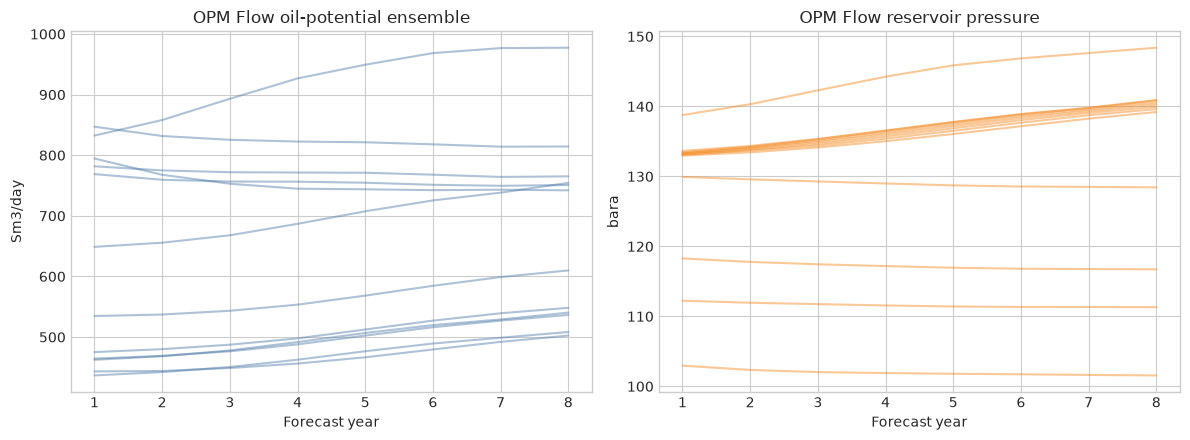

In [13]:
field_forecast = reservoir.groupby(
    ["realization_id", "scenario_key", "year"], as_index=False
).agg(
    oil_potential_sm3_day=("oil_potential_sm3_day", "sum"),
    water_rate_sm3_day=("water_rate_sm3_day", "sum"),
    gas_potential_msm3_day=("gas_potential_msm3_day", "sum"),
    field_pressure_bara=("field_pressure_bara", "mean"),
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for _, group in field_forecast.groupby("scenario_key"):
    axes[0].plot(
        group.year,
        group.oil_potential_sm3_day,
        color="#4C78A8",
        alpha=0.45,
    )
    axes[1].plot(
        group.year,
        group.field_pressure_bara,
        color="#F58518",
        alpha=0.45,
    )
axes[0].set(title="OPM Flow oil-potential ensemble", ylabel="Sm3/day")
axes[1].set(title="OPM Flow reservoir pressure", ylabel="bara")
for axis in axes:
    axis.set_xlabel("Forecast year")
fig.tight_layout()
plt.show()

## 5. NeqSim well and SURF response

A gas-rich multiphase fluid is transported from reservoir pressure through 2,600 m
of vertical tubing and a 12 km subsea flowline. The direct Beggs–Brill calculations
span the expected gas-rate range. The fitted response is only an optimization
surrogate; direct NeqSim points remain in the audit table and all extrapolation is
prohibited.

In [14]:
def base_fluid(temperature_c, pressure_bara):
    fluid = SystemSrkCPAstatoil(
        273.15 + float(temperature_c), float(pressure_bara)
    )
    for name, amount in [
        ("methane", 80.0),
        ("ethane", 7.0),
        ("propane", 4.0),
        ("n-butane", 2.0),
        ("n-pentane", 1.0),
        ("water", 3.0),
    ]:
        fluid.addComponent(name, amount)
    fluid.addTBPfraction("C10", 3.0, 0.142, 0.78)
    fluid.setMixingRule(10)
    fluid.setMultiPhaseCheck(True)
    fluid.init(0)
    return fluid

def run_well_surf(gas_rate_msm3_day, case_id):
    feed = Stream(
        f"reservoir feed {case_id}", base_fluid(80.0, 250.0)
    )
    feed.setFlowRate(float(gas_rate_msm3_day), "MSm3/day")
    feed.setPressure(250.0, "bara")
    feed.setTemperature(80.0, "C")
    feed.run()
    tubing = PipeBeggsAndBrills(f"vertical tubing {case_id}", feed)
    tubing.setLength(2600.0)
    tubing.setDiameter(0.18)
    tubing.setPipeWallRoughness(1.0e-5)
    tubing.setElevation(2400.0)
    tubing.setNumberOfIncrements(30)
    tubing.setConstantSurfaceTemperature(10.0, "C")
    tubing.setOuterHeatTransferCoefficient(7.0)
    tubing.run()
    flowline = PipeBeggsAndBrills(
        f"subsea flowline {case_id}", tubing.getOutletStream()
    )
    flowline.setLength(12000.0)
    flowline.setDiameter(0.30)
    flowline.setPipeWallRoughness(1.0e-5)
    flowline.setElevation(0.0)
    flowline.setNumberOfIncrements(30)
    flowline.setConstantSurfaceTemperature(5.0, "C")
    flowline.setOuterHeatTransferCoefficient(12.0)
    flowline.run()
    return {
        "gas_rate_msm3_day": gas_rate_msm3_day,
        "wellhead_pressure_bara": tubing.getOutletStream().getPressure(
            "bara"
        ),
        "arrival_pressure_bara": flowline.getOutletStream().getPressure(
            "bara"
        ),
        "arrival_temperature_c": flowline.getOutletStream().getTemperature(
            "C"
        ),
    }

In [15]:
rate_grid = np.linspace(0.25, 3.25, 7)
well_surf = pd.DataFrame(
    [
        run_well_surf(rate, f"map-{index:02d}")
        for index, rate in enumerate(rate_grid)
    ]
)
arrival_coefficients = np.polyfit(
    well_surf.gas_rate_msm3_day,
    well_surf.arrival_pressure_bara,
    deg=3,
)
well_surf["fitted_arrival_bara"] = np.polyval(
    arrival_coefficients, well_surf.gas_rate_msm3_day
)
well_surf["fit_error_bar"] = (
    well_surf.fitted_arrival_bara - well_surf.arrival_pressure_bara
)
display(well_surf.round(3))
assert well_surf.fit_error_bar.abs().max() < 1.0

,gas_rate_msm3_day,wellhead_pressure_bara,arrival_pressure_bara,arrival_temperature_c,fitted_arrival_bara,fit_error_bar
0,0.25,158.084,158.059,5.000,158.363,0.304
1,0.75,166.328,166.138,4.999,165.388,-0.750
2,1.25,168.206,167.712,4.995,167.918,0.206
3,1.75,167.558,166.665,4.996,167.261,0.596
4,2.25,166.321,164.809,4.993,164.726,-0.084
5,2.75,164.609,162.140,4.988,161.622,-0.518
6,3.25,162.504,159.014,4.982,159.260,0.246


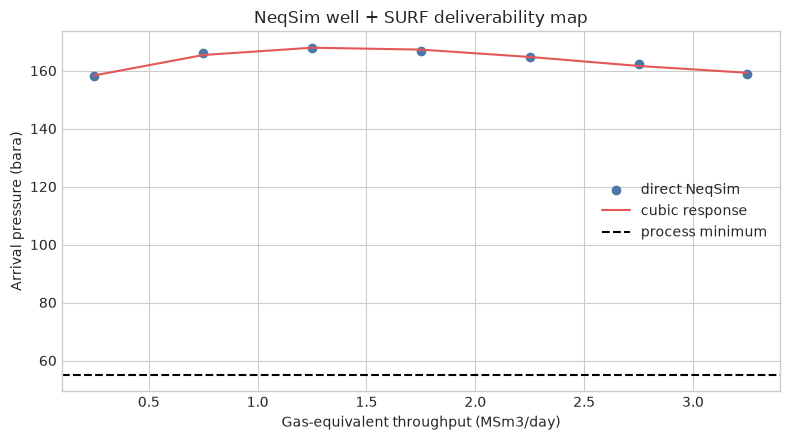

In [16]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(
    well_surf.gas_rate_msm3_day,
    well_surf.arrival_pressure_bara,
    label="direct NeqSim",
    color="#4C78A8",
)
ax.plot(
    well_surf.gas_rate_msm3_day,
    well_surf.fitted_arrival_bara,
    label="cubic response",
    color="#E45756",
)
ax.axhline(55.0, color="black", linestyle="--", label="process minimum")
ax.set(
    xlabel="Gas-equivalent throughput (MSm3/day)",
    ylabel="Arrival pressure (bara)",
    title="NeqSim well + SURF deliverability map",
)
ax.legend()
fig.tight_layout()
plt.show()

In [17]:
field_forecast["arrival_pressure_bara"] = np.polyval(
    arrival_coefficients,
    field_forecast.gas_potential_msm3_day.clip(
        rate_grid.min(), rate_grid.max()
    ),
)
field_forecast["surf_factor"] = np.clip(
    (field_forecast.arrival_pressure_bara - 50.0) / 35.0,
    0.55,
    1.0,
)
reservoir = reservoir.merge(
    field_forecast[
        ["realization_id", "year", "arrival_pressure_bara", "surf_factor"]
    ],
    on=["realization_id", "year"],
    validate="many_to_one",
)
reservoir["deliverable_oil_sm3_day"] = (
    reservoir.oil_potential_sm3_day * reservoir.surf_factor
)
print(
    "SURF derating range:",
    f"{reservoir.surf_factor.min():.3f}–{reservoir.surf_factor.max():.3f}",
)

SURF derating range: 1.000–1.000


## 6. NeqSim host process response

Direct process cases use a feed valve, three-phase separator, export compressor, and
aftercooler. The optimization uses a linearized power slope plus a fixed cost for the
second train. Mass closure and equipment-sign conventions are checked before the map
is accepted.

In [18]:
def run_process_case(gas_rate_msm3_day, case_id):
    feed = Stream(f"process feed {case_id}", base_fluid(20.0, 80.0))
    feed.setFlowRate(float(gas_rate_msm3_day), "MSm3/day")
    feed.setPressure(80.0, "bara")
    feed.setTemperature(20.0, "C")
    valve = ThrottlingValve(f"inlet valve {case_id}", feed)
    valve.setOutletPressure(55.0, "bara")
    separator = ThreePhaseSeparator(
        f"three phase separator {case_id}", valve.getOutletStream()
    )
    compressor = Compressor(
        f"export compressor {case_id}", separator.getGasOutStream()
    )
    compressor.setOutletPressure(120.0, "bara")
    compressor.setIsentropicEfficiency(0.78)
    cooler = Cooler(f"export cooler {case_id}", compressor.getOutletStream())
    cooler.setOutTemperature(35.0, "C")
    process = ProcessSystem()
    for unit in [feed, valve, separator, compressor, cooler]:
        process.add(unit)
    process.run()
    feed_mass = feed.getFlowRate("kg/sec")
    product_mass = sum(
        stream.getFlowRate("kg/sec")
        for stream in [
            separator.getGasOutStream(),
            separator.getOilOutStream(),
            separator.getWaterOutStream(),
        ]
    )
    return {
        "gas_rate_msm3_day": gas_rate_msm3_day,
        "compressor_power_mw": compressor.getPower("MW"),
        "cooler_duty_mw": cooler.getDuty() / 1.0e6,
        "feed_mass_kg_s": feed_mass,
        "product_mass_kg_s": product_mass,
        "relative_mass_error": abs(feed_mass - product_mass) / feed_mass,
    }

In [19]:
process_grid = np.linspace(0.30, 3.20, 12)
process_map = pd.DataFrame(
    [
        run_process_case(rate, f"map-{index:02d}")
        for index, rate in enumerate(process_grid)
    ]
)
power_slope, power_intercept = np.polyfit(
    process_map.gas_rate_msm3_day,
    process_map.compressor_power_mw,
    1,
)
process_map["fitted_power_mw"] = (
    power_intercept + power_slope * process_map.gas_rate_msm3_day
)
display(process_map.round(4))
assert process_map.relative_mass_error.max() < 1.0e-8
assert (process_map.compressor_power_mw > 0.0).all()
assert (process_map.cooler_duty_mw < 0.0).all()

,gas_rate_msm3_day,compressor_power_mw,cooler_duty_mw,feed_mass_kg_s,product_mass_kg_s,relative_mass_error,fitted_power_mw
0,0.3000,0.2893,-0.3136,3.4344,3.4344,0.0,0.2893
1,0.5636,0.5436,-0.5892,6.4526,6.4526,0.0,0.5436
2,0.8273,0.7979,-0.8648,9.4707,9.4707,0.0,0.7979
3,1.0909,1.0522,-1.1404,12.4889,12.4889,0.0,1.0522
4,1.3545,1.3064,-1.4161,15.5070,15.5070,0.0,1.3064
5,1.6182,1.5607,-1.6917,18.5252,18.5252,0.0,1.5607
6,1.8818,1.8150,-1.9673,21.5433,21.5433,0.0,1.8150
7,2.1455,2.0693,-2.2429,24.5615,24.5615,0.0,2.0693
8,2.4091,2.3236,-2.5185,27.5796,27.5796,0.0,2.3236
9,2.6727,2.5778,-2.7941,30.5978,30.5978,0.0,2.5778


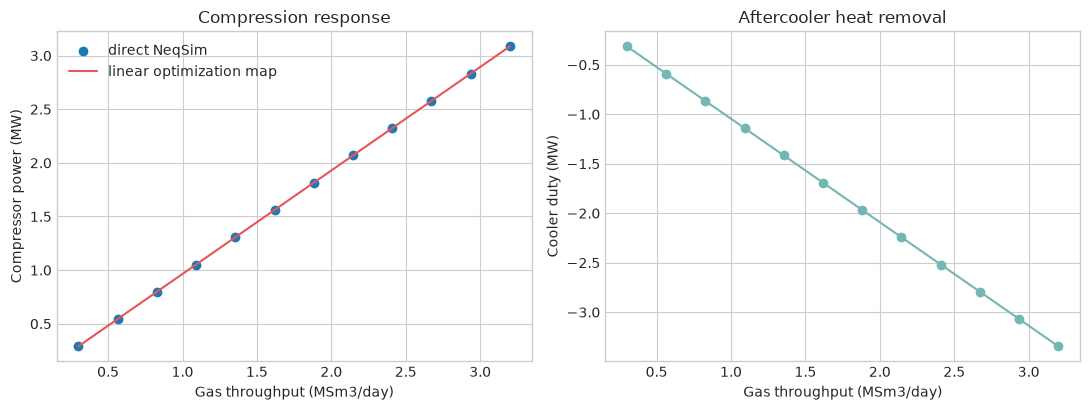

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].scatter(
    process_map.gas_rate_msm3_day,
    process_map.compressor_power_mw,
    label="direct NeqSim",
)
axes[0].plot(
    process_map.gas_rate_msm3_day,
    process_map.fitted_power_mw,
    color="#E45756",
    label="linear optimization map",
)
axes[0].set(
    xlabel="Gas throughput (MSm3/day)",
    ylabel="Compressor power (MW)",
    title="Compression response",
)
axes[0].legend()
axes[1].plot(
    process_map.gas_rate_msm3_day,
    process_map.cooler_duty_mw,
    marker="o",
    color="#72B7B2",
)
axes[1].set(
    xlabel="Gas throughput (MSm3/day)",
    ylabel="Cooler duty (MW)",
    title="Aftercooler heat removal",
)
fig.tight_layout()
plt.show()

## 7. One reservoir/process/economic ledger

The next join is the heart of the study. It uses `realization_id` and year, validates
cardinality, and records both source paths and NeqSim commit. The resulting table is
the only input to optimization. A randomly recombined price, GOR, process response,
or reservoir percentile is therefore structurally excluded.

In [21]:
ledger = reservoir.merge(
    scenarios[
        [
            "realization_id",
            "OIL_PRICE",
            "GAS_PRICE",
            "HOST_RESERVE_FEE",
            "probability",
            "scenario_key",
        ]
    ],
    on=["realization_id", "scenario_key"],
    validate="many_to_one",
)
ledger["neqsim_commit"] = NEQSIM_COMMIT
ledger["opm_deck"] = ledger.scenario_key.map(
    lambda key: str(FLOW_ROOT / key / "FIELD.DATA")
)
ledger["ert_runpath"] = ledger.realization_id.map(
    lambda rid: str(ERT_ROOT / "runs" / f"realization-{rid}" / "iter-0")
)
ledger["gas_factor_msm3_per_sm3_oil"] = ledger.GOR / 1.0e6
ledger["water_factor"] = ledger.water_cut / np.maximum(
    1.0 - ledger.water_cut, 1.0e-6
)
ledger_path = OUTPUT_ROOT / "internally_consistent_scenario_ledger.csv"
ledger.to_csv(ledger_path, index=False)
display(
    ledger[
        [
            "scenario_key",
            "year",
            "well",
            "deliverable_oil_sm3_day",
            "GOR",
            "OIL_PRICE",
            "GAS_PRICE",
            "AVAILABILITY",
            "arrival_pressure_bara",
        ]
    ].head(12).round(3)
)
print(f"Ledger rows: {len(ledger)}; path: {ledger_path}")

Ledger rows: 288; path: stochastic_reservoir_market_outputs/internally_consistent_scenario_ledger.csv


,scenario_key,year,well,deliverable_oil_sm3_day,GOR,OIL_PRICE,GAS_PRICE,AVAILABILITY,arrival_pressure_bara
0,R000,1,P1,110.839,200.898,516.297,3.135,0.95,158.363
1,R000,1,P2,162.909,200.898,516.297,3.135,0.95,158.363
2,R000,1,P3,162.909,200.898,516.297,3.135,0.95,158.363
3,R000,2,P1,111.766,200.898,516.297,3.135,0.95,158.363
4,R000,2,P2,165.190,200.898,516.297,3.135,0.95,158.363
5,R000,2,P3,165.190,200.898,516.297,3.135,0.95,158.363
6,R000,3,P1,113.721,200.898,516.297,3.135,0.95,158.363
7,R000,3,P2,168.408,200.898,516.297,3.135,0.95,158.363
8,R000,3,P3,168.408,200.898,516.297,3.135,0.95,158.363
9,R000,4,P1,116.632,200.898,516.297,3.135,0.95,158.363


### Why independent P10/P50/P90 splicing is invalid

A tempting shortcut chooses a low reservoir case, median GOR/process case, and high
price case independently. The constructed tuple below has no ERT realization ID, no
OPM deck, and no joint probability. It is shown only as an anti-pattern and is never
passed to Pyomo.

In [22]:
invalid_splice = pd.Series(
    {
        "oil_potential_P90": field_forecast.oil_potential_sm3_day.quantile(0.10),
        "GOR_P50": scenarios.GOR.quantile(0.50),
        "oil_price_P10": scenarios.OIL_PRICE.quantile(0.90),
        "realization_id": pd.NA,
        "joint_probability": pd.NA,
        "usable_for_optimization": False,
    },
    name="invalid independent percentile splice",
)
display(invalid_splice.to_frame("value"))
assert pd.isna(invalid_splice.realization_id)

,value
oil_potential_P90,465.460903
GOR_P50,166.352061
oil_price_P10,708.791628
realization_id,<NA>
joint_probability,<NA>
usable_for_optimization,False


## 8. Pyomo stochastic optimization

For each scenario $s$, year $t$, and well $w$, $q_{s,t,w}$ is accepted oil rate and
is bounded by the NeqSim-derated OPM potential. Gas and water are linear functions of
accepted oil. The binary $d_{s,t}$ activates a second compressor train. Host
holdback $h_{s,t}$ reserves capacity for third-party service and earns its scenario
fee. Upgrade start $x_t$ is common across every realization.

$$\sum_w q_{s,t,w}+h_{s,t}\leq Q^{\mathrm{oil}}_0+
\Delta Q^{\mathrm{oil}}a_t$$

$$\sum_w g_{s,w}q_{s,t,w}\leq G_0+\Delta G^{\mathrm{dual}}d_{s,t}+
\Delta G^{\mathrm{up}}a_t$$

The objective includes oil and gas revenue, water handling, compression power,
variable operating cost, dual-train fixed cost, host reservation income, and upgrade
capital. Annual rates are multiplied by uptime and days per year.

In [23]:
records = ledger.set_index(["realization_id", "year", "well"])
MEAN_SCENARIO = 999
mean_records = ledger.groupby(["year", "well"], as_index=False).mean(
    numeric_only=True
)
mean_records["realization_id"] = MEAN_SCENARIO
mean_records = mean_records.set_index(["realization_id", "year", "well"])
records = pd.concat([records, mean_records], axis=0)
economic_inputs = scenarios.set_index("realization_id")[
    ["AVAILABILITY", "OIL_PRICE", "GAS_PRICE", "HOST_RESERVE_FEE"]
].copy()
economic_inputs.loc[MEAN_SCENARIO] = economic_inputs.mean(axis=0)
scenario_index = sorted(ledger.realization_id.unique())
year_index = list(map(int, YEARS))

def build_model(fixed_upgrade="free", scenario_subset=None):
    selected = scenario_index if scenario_subset is None else scenario_subset
    model = pyo.ConcreteModel()
    model.S = pyo.Set(initialize=selected)
    model.Y = pyo.Set(initialize=year_index, ordered=True)
    model.W = pyo.Set(initialize=WELLS)
    model.q = pyo.Var(model.S, model.Y, model.W, domain=pyo.NonNegativeReals)
    model.compressor_dual = pyo.Var(
        model.S, model.Y, domain=pyo.Binary
    )
    model.holdback = pyo.Var(
        model.S, model.Y, domain=pyo.NonNegativeReals
    )
    model.upgrade_start = pyo.Var(model.Y, domain=pyo.Binary)

    if fixed_upgrade != "free":
        for year in year_index:
            model.upgrade_start[year].fix(
                1 if fixed_upgrade == year else 0
            )

    model.one_upgrade = pyo.Constraint(
        expr=sum(model.upgrade_start[y] for y in model.Y) <= 1
    )

    def active(m, year):
        return sum(m.upgrade_start[y] for y in m.Y if y <= year)

    def potential_limit(m, scenario, year, well):
        return m.q[scenario, year, well] <= float(
            records.loc[(scenario, year, well), "deliverable_oil_sm3_day"]
        )

    model.potential = pyo.Constraint(
        model.S, model.Y, model.W, rule=potential_limit
    )

    def oil_capacity(m, scenario, year):
        return (
            sum(m.q[scenario, year, well] for well in m.W)
            + m.holdback[scenario, year]
            <= 750.0 + 300.0 * active(m, year)
        )

    model.oil_capacity = pyo.Constraint(
        model.S, model.Y, rule=oil_capacity
    )

    def gas_capacity(m, scenario, year):
        gas = sum(
            m.q[scenario, year, well]
            * float(
                records.loc[
                    (scenario, year, well),
                    "gas_factor_msm3_per_sm3_oil",
                ]
            )
            for well in m.W
        )
        return gas <= (
            0.09
            + 0.065 * m.compressor_dual[scenario, year]
            + 0.04 * active(m, year)
        )

    model.gas_capacity = pyo.Constraint(
        model.S, model.Y, rule=gas_capacity
    )

    def water_capacity(m, scenario, year):
        return sum(
            m.q[scenario, year, well]
            * float(records.loc[(scenario, year, well), "water_factor"])
            for well in m.W
        ) <= 1450.0 + 500.0 * active(m, year)

    model.water_capacity = pyo.Constraint(
        model.S, model.Y, rule=water_capacity
    )

    probability = 1.0 / len(selected)
    annual_terms = []
    for scenario in selected:
        scenario_data = economic_inputs.loc[scenario]
        for year in year_index:
            discount = (1.0 + DISCOUNT_RATE) ** year
            oil_margin = float(scenario_data.OIL_PRICE) - 78.0
            oil = sum(model.q[scenario, year, well] for well in WELLS)
            oil_profit = sum(
                model.q[scenario, year, well]
                * (oil_margin - WELL_LIFT_COST_NOK_SM3[well])
                for well in WELLS
            )
            gas = sum(
                model.q[scenario, year, well]
                * float(
                    records.loc[
                        (scenario, year, well),
                        "gas_factor_msm3_per_sm3_oil",
                    ]
                )
                for well in WELLS
            )
            water = sum(
                model.q[scenario, year, well]
                * float(
                    records.loc[(scenario, year, well), "water_factor"]
                )
                for well in WELLS
            )
            uptime_days = DAYS_PER_YEAR * float(
                scenario_data.AVAILABILITY
            )
            gas_margin = float(scenario_data.GAS_PRICE) * 1.0e6
            compression_cost = 640.0 * 24.0 * power_slope * gas
            operating_profit = uptime_days * (
                oil_profit
                + gas_margin * gas
                - 28.0 * water
                - compression_cost
                + float(scenario_data.HOST_RESERVE_FEE)
                * model.holdback[scenario, year]
            )
            fixed_dual = 8.0e6 * model.compressor_dual[scenario, year]
            annual_terms.append(
                probability * (operating_profit - fixed_dual) / discount
            )
    upgrade_capex = sum(
        UPGRADE_CAPEX_NOK * model.upgrade_start[year]
        / (1.0 + DISCOUNT_RATE) ** year
        for year in year_index
    )
    model.objective = pyo.Objective(
        expr=sum(annual_terms) - upgrade_capex,
        sense=pyo.maximize,
    )
    return model

In [24]:
solver = pyo.SolverFactory("appsi_highs")
stochastic_model = build_model()
solution = solver.solve(stochastic_model)
assert solution.solver.termination_condition == pyo.TerminationCondition.optimal
stochastic_npv = pyo.value(stochastic_model.objective)
upgrade_years = [
    year
    for year in YEARS
    if pyo.value(stochastic_model.upgrade_start[int(year)]) > 0.5
]
stochastic_upgrade = int(upgrade_years[0]) if upgrade_years else None
print(f"Expected stochastic NPV: {stochastic_npv / 1e9:.3f} bn NOK")
print(f"Common upgrade start: {stochastic_upgrade or 'no upgrade'}")

Expected stochastic NPV: 1.121 bn NOK
Common upgrade start: no upgrade


In [25]:
decision_rows = []
for scenario in scenario_index:
    for year in year_index:
        oil = sum(
            pyo.value(stochastic_model.q[scenario, year, well])
            for well in WELLS
        )
        gas = sum(
            pyo.value(stochastic_model.q[scenario, year, well])
            * float(
                records.loc[
                    (scenario, year, well),
                    "gas_factor_msm3_per_sm3_oil",
                ]
            )
            for well in WELLS
        )
        decision_rows.append(
            {
                "realization_id": scenario,
                "scenario_key": f"R{scenario:03d}",
                "year": year,
                "oil_sm3_day": oil,
                "gas_msm3_day": gas,
                "holdback_sm3_day": pyo.value(
                    stochastic_model.holdback[scenario, year]
                ),
                "dual_compressor": round(
                    pyo.value(
                        stochastic_model.compressor_dual[scenario, year]
                    )
                ),
            }
        )
decisions = pd.DataFrame(decision_rows)
display(decisions.head(12).round(3))

,realization_id,scenario_key,year,oil_sm3_day,gas_msm3_day,holdback_sm3_day,dual_compressor
0,0,R000,1,436.656,0.088,313.344,0
1,0,R000,2,442.146,0.089,307.854,0
2,0,R000,3,447.989,0.090,302.011,0
3,0,R000,4,447.989,0.090,302.011,0
4,0,R000,5,476.577,0.096,273.423,1
5,0,R000,6,489.298,0.098,260.702,1
6,0,R000,7,498.834,0.100,251.166,1
7,0,R000,8,508.319,0.102,241.681,1
8,1,R001,1,750.000,0.114,0.000,1
9,1,R001,2,750.000,0.114,0.000,1


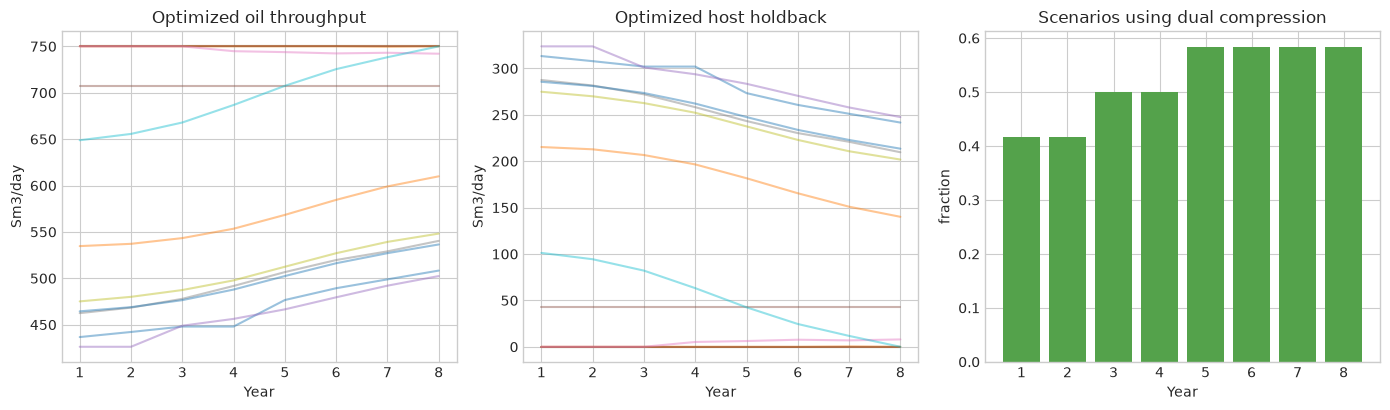

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for _, group in decisions.groupby("scenario_key"):
    axes[0].plot(group.year, group.oil_sm3_day, alpha=0.45)
    axes[1].plot(group.year, group.holdback_sm3_day, alpha=0.45)
dual_share = decisions.groupby("year").dual_compressor.mean()
axes[2].bar(dual_share.index, dual_share.values, color="#54A24B")
axes[0].set(title="Optimized oil throughput", ylabel="Sm3/day")
axes[1].set(title="Optimized host holdback", ylabel="Sm3/day")
axes[2].set(title="Scenarios using dual compression", ylabel="fraction")
for axis in axes:
    axis.set_xlabel("Year")
fig.tight_layout()
plt.show()

## 9. Scenario NPV, P90/P50/P10, VSS, and EVPI

We re-evaluate each realization with the common stochastic upgrade policy to obtain
its full-chain NPV. Quantiles are selected by nearest ranked scenario, retaining all
inputs and decisions. VSS compares the stochastic policy with the policy chosen from
expected inputs. EVPI compares the stochastic policy with a different fully informed
upgrade decision for every scenario.

In [27]:
def solve_policy_for_scenario(scenario, fixed_upgrade):
    model = build_model(
        fixed_upgrade=fixed_upgrade,
        scenario_subset=[scenario],
    )
    result = solver.solve(model)
    assert result.solver.termination_condition == pyo.TerminationCondition.optimal
    return pyo.value(model.objective)

scenario_values = []
for scenario in scenario_index:
    scenario_values.append(
        {
            "realization_id": scenario,
            "scenario_key": f"R{scenario:03d}",
            "npv_nok": solve_policy_for_scenario(
                scenario, stochastic_upgrade
            ),
        }
    )
scenario_npv = pd.DataFrame(scenario_values).merge(
    scenarios,
    on=["realization_id", "scenario_key"],
    validate="one_to_one",
)
ranked = scenario_npv.sort_values("npv_nok").reset_index(drop=True)

def nearest_complete_scenario(fractile):
    index = int(round(fractile * (len(ranked) - 1)))
    return ranked.iloc[index]

fractiles = pd.DataFrame(
    [
        {"label": "P90 (low)", **nearest_complete_scenario(0.10).to_dict()},
        {"label": "P50", **nearest_complete_scenario(0.50).to_dict()},
        {"label": "P10 (high)", **nearest_complete_scenario(0.90).to_dict()},
    ]
)
display(
    fractiles[
        [
            "label",
            "scenario_key",
            "npv_nok",
            "POROSITY",
            "PERMEABILITY_MD",
            "GOR",
            "OIL_PRICE",
            "GAS_PRICE",
            "AVAILABILITY",
        ]
    ].assign(npv_bn_nok=lambda x: x.npv_nok / 1e9).round(3)
)

,label,scenario_key,npv_nok,POROSITY,PERMEABILITY_MD,GOR,OIL_PRICE,GAS_PRICE,AVAILABILITY,npv_bn_nok
0,P90 (low),R011,8.256861e+08,0.239,85.276,122.739,605.426,2.050,0.895,0.826
1,P50,R007,1.057281e+09,0.192,73.813,132.033,680.091,3.924,0.896,1.057
2,P10 (high),R005,1.441195e+09,0.238,188.681,219.308,428.247,3.417,0.920,1.441


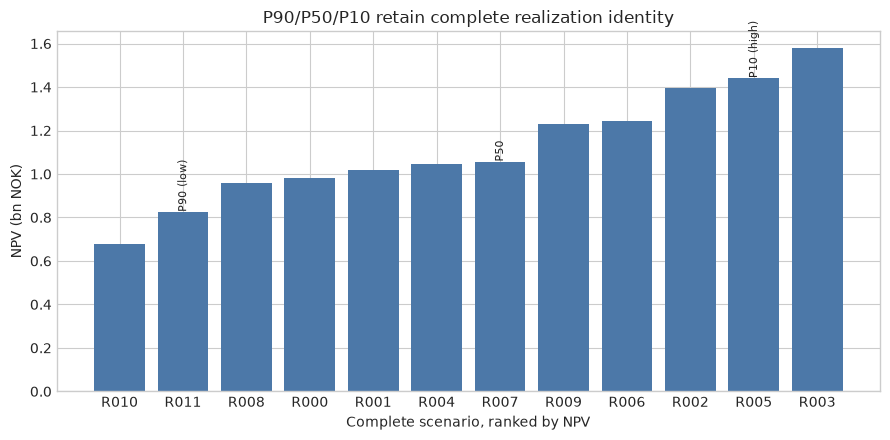

In [28]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#4C78A8"] * len(ranked)
ax.bar(ranked.scenario_key, ranked.npv_nok / 1e9, color=colors)
for _, row in fractiles.iterrows():
    position = ranked.index[ranked.scenario_key == row.scenario_key][0]
    ax.text(
        position,
        row.npv_nok / 1e9,
        row.label,
        rotation=90,
        va="bottom",
        ha="center",
        fontsize=8,
    )
ax.set(
    xlabel="Complete scenario, ranked by NPV",
    ylabel="NPV (bn NOK)",
    title="P90/P50/P10 retain complete realization identity",
)
fig.tight_layout()
plt.show()

In [29]:
policy_candidates = [None] + list(map(int, YEARS))
candidate_values = []
for candidate in policy_candidates:
    value = np.mean(
        [
            solve_policy_for_scenario(scenario, candidate)
            for scenario in scenario_index
        ]
    )
    candidate_values.append(
        {"upgrade_year": candidate, "expected_npv_nok": value}
    )
candidate_table = pd.DataFrame(candidate_values)
best_stochastic_candidate = candidate_table.loc[
    candidate_table.expected_npv_nok.idxmax(), "upgrade_year"
]

mean_model = build_model(scenario_subset=[MEAN_SCENARIO])
mean_result = solver.solve(mean_model)
assert (
    mean_result.solver.termination_condition
    == pyo.TerminationCondition.optimal
)
mean_upgrade_years = [
    year
    for year in YEARS
    if pyo.value(mean_model.upgrade_start[int(year)]) > 0.5
]
expected_value_policy = (
    int(mean_upgrade_years[0]) if mean_upgrade_years else None
)
expected_value_npv = float(
    np.mean(
        [
            solve_policy_for_scenario(scenario, expected_value_policy)
            for scenario in scenario_index
        ]
    )
)

perfect_values = []
perfect_policy_rows = []
for scenario in scenario_index:
    alternatives = [
        solve_policy_for_scenario(scenario, candidate)
        for candidate in policy_candidates
    ]
    best_index = int(np.argmax(alternatives))
    perfect_values.append(alternatives[best_index])
    perfect_policy_rows.append(
        {
            "scenario_key": f"R{scenario:03d}",
            "perfect_information_upgrade": policy_candidates[best_index],
            "perfect_information_npv_nok": alternatives[best_index],
        }
    )
perfect_information_npv = float(np.mean(perfect_values))
vss = stochastic_npv - expected_value_npv
evpi = perfect_information_npv - stochastic_npv
value_summary = pd.DataFrame(
    {
        "metric": [
            "stochastic expected NPV",
            "expected-policy NPV",
            "perfect-information NPV",
            "VSS",
            "EVPI",
        ],
        "bn_NOK": np.array(
            [
                stochastic_npv,
                expected_value_npv,
                perfect_information_npv,
                vss,
                evpi,
            ]
        )
        / 1.0e9,
    }
)
display(candidate_table.assign(nvp_bn_nok=lambda x: x.expected_npv_nok / 1e9))
print(
    "Expected-value model upgrade policy:",
    expected_value_policy if expected_value_policy else "no upgrade",
)
display(value_summary.round(4))
display(pd.DataFrame(perfect_policy_rows))

Expected-value model upgrade policy: no upgrade


,upgrade_year,expected_npv_nok,nvp_bn_nok
0,NaN,1.120563e+09,1.120563
1,1.0,1.065710e+09,1.065710
2,2.0,1.061889e+09,1.061889
3,3.0,1.058981e+09,1.058981
4,4.0,1.056064e+09,1.056064
5,5.0,1.052948e+09,1.052948
6,6.0,1.049605e+09,1.049605
7,7.0,1.046364e+09,1.046364
8,8.0,1.043382e+09,1.043382


,metric,bn_NOK
0,stochastic expected NPV,1.1206
1,expected-policy NPV,1.1206
2,perfect-information NPV,1.1460
3,VSS,0.0000
4,EVPI,0.0254


,scenario_key,perfect_information_upgrade,perfect_information_npv_nok
0,R000,NaN,9.798936e+08
1,R001,NaN,1.016705e+09
2,R002,1.0,1.579242e+09
3,R003,NaN,1.577436e+09
4,R004,NaN,1.046149e+09
5,R005,1.0,1.561648e+09
6,R006,NaN,1.241995e+09
7,R007,NaN,1.057281e+09
8,R008,NaN,9.573945e+08
9,R009,NaN,1.229731e+09


`expected-policy NPV` evaluates over all original realizations the upgrade policy
selected by a separate deterministic model built from mean inputs. The candidate
table is a transparent cross-check of every common upgrade year under the full
ensemble. VSS can be zero when the mean-input and stochastic policies coincide; that
is a result, not an assumption. EVPI remains the upper value of learning the scenario
before committing the upgrade.

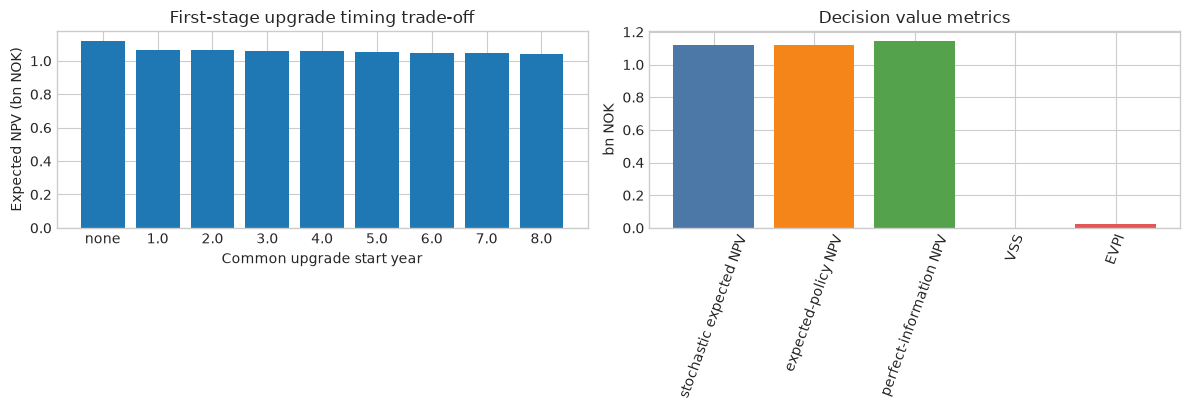

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
labels = candidate_table.upgrade_year.fillna("none").astype(str)
axes[0].bar(labels, candidate_table.expected_npv_nok / 1e9)
axes[0].set(
    xlabel="Common upgrade start year",
    ylabel="Expected NPV (bn NOK)",
    title="First-stage upgrade timing trade-off",
)
axes[1].bar(
    value_summary.metric,
    value_summary.bn_NOK,
    color=["#4C78A8", "#F58518", "#54A24B", "#B279A2", "#E45756"],
)
axes[1].tick_params(axis="x", rotation=70)
axes[1].set(ylabel="bn NOK", title="Decision value metrics")
fig.tight_layout()
plt.show()

## 10. Constraint diagnostics and operational interpretation

Choke allocation should favor wells with the best joint oil, GOR, and water-handling
contribution—not simply the largest OPM potential. Dual compression is scenario and
year specific. Holdback occupies host capacity only when the consistent third-party
fee supports it or own-production potential leaves capacity unused.

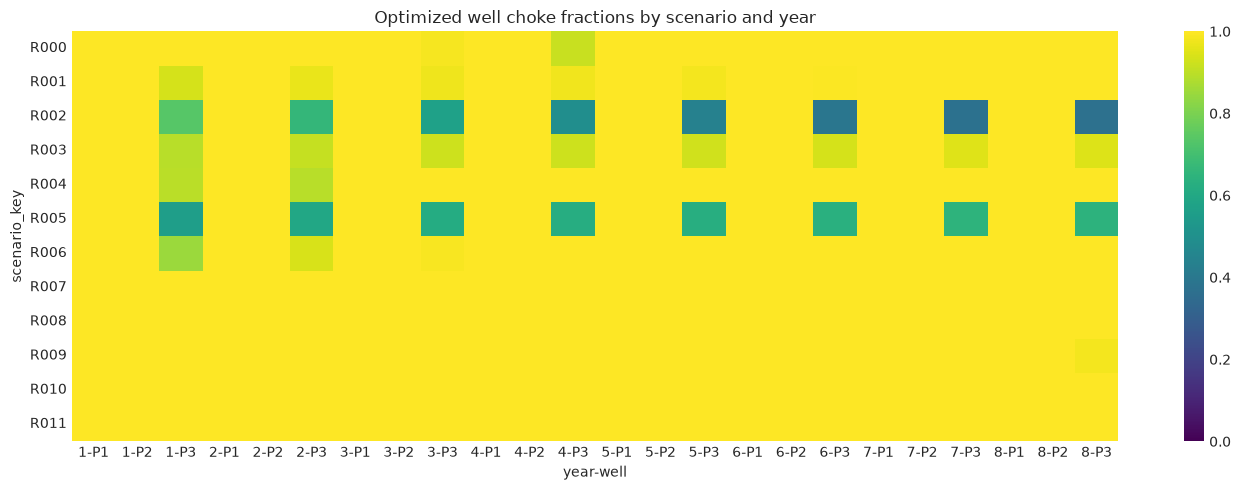

In [31]:
choke_rows = []
for scenario in scenario_index:
    for year in year_index:
        for well in WELLS:
            potential = float(
                records.loc[(scenario, year, well), "deliverable_oil_sm3_day"]
            )
            accepted = pyo.value(stochastic_model.q[scenario, year, well])
            choke_rows.append(
                {
                    "scenario_key": f"R{scenario:03d}",
                    "year": year,
                    "well": well,
                    "choke_fraction": accepted / max(potential, 1.0e-9),
                }
            )
choke_table = pd.DataFrame(choke_rows)
choke_pivot = choke_table.pivot_table(
    index="scenario_key",
    columns=["year", "well"],
    values="choke_fraction",
)
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(choke_pivot, vmin=0, vmax=1, cmap="viridis", ax=ax)
ax.set_title("Optimized well choke fractions by scenario and year")
fig.tight_layout()
plt.show()

## 11. Automated engineering and lineage checks

These checks are deliberately visible. A notebook that only reaches an optimizer
status is not enough: the simulator runs, response maps, joins, probabilities,
physical signs, non-anticipativity, and percentile identity all need independent
assertions.

In [32]:
checks = {
    "NeqSim class loaded from source-built JAR": str(NEQSIM_JAR) in class_source,
    "NeqSim master commit recorded": len(NEQSIM_COMMIT) == 40,
    "ERT lint passed": lint.returncode == 0,
    "ERT run succeeded": ert_run.returncode == 0,
    "ERT realization count": len(run_dirs) == N_SCENARIOS,
    "ERT probability closes": np.isclose(scenarios.probability.sum(), 1.0),
    "correlation matrix positive definite": eigenvalues.min() > 0,
    "OPM run count": len(flow_runs) == N_SCENARIOS,
    "all OPM return codes zero": all(
        run["flow_return_code"] == 0 for run in flow_runs
    ),
    "reservoir row count": len(reservoir) == N_SCENARIOS * len(YEARS) * 3,
    "oil potential nonnegative": (reservoir.oil_potential_sm3_day >= 0).all(),
    "water cut bounded": reservoir.water_cut.between(0, 1).all(),
    "well/SURF response fit bounded": well_surf.fit_error_bar.abs().max() < 1,
    "arrival pressure positive": (well_surf.arrival_pressure_bara > 0).all(),
    "process mass closure": process_map.relative_mass_error.max() < 1e-8,
    "compressor power positive": (process_map.compressor_power_mw > 0).all(),
    "cooler removes heat": (process_map.cooler_duty_mw < 0).all(),
    "ledger key unique": not ledger.duplicated(
        ["realization_id", "year", "well"]
    ).any(),
    "ledger commit single-valued": ledger.neqsim_commit.nunique() == 1,
    "invalid splice rejected": not invalid_splice.usable_for_optimization,
    "stochastic solve optimal": (
        solution.solver.termination_condition
        == pyo.TerminationCondition.optimal
    ),
    "at most one common upgrade": len(upgrade_years) <= 1,
    "chokes bounded": choke_table.choke_fraction.between(
        -1e-7, 1 + 1e-7
    ).all(),
    "choke allocation is nontrivial": (
        (choke_table.choke_fraction < 0.999).any()
        and (choke_table.choke_fraction > 0.999).any()
    ),
    "both compressor configurations used": set(
        decisions.dual_compressor.unique()
    ) == {0, 1},
    "host holdback has active and zero states": (
        decisions.holdback_sm3_day.max() > 1.0
        and decisions.holdback_sm3_day.min() < 1.0e-6
    ),
    "VSS nonnegative within tolerance": vss >= -1e-3,
    "EVPI nonnegative within tolerance": evpi >= -1e-3,
    "fractiles retain realization IDs": fractiles.realization_id.notna().all(),
}
check_table = pd.DataFrame(
    {"check": checks.keys(), "passed": checks.values()}
)
display(check_table)
print(f"Passed {check_table.passed.sum()}/{len(check_table)} checks")
assert check_table.passed.all()

Passed 29/29 checks


,check,passed
0,NeqSim class loaded from source-built JAR,True
1,NeqSim master commit recorded,True
2,ERT lint passed,True
3,ERT run succeeded,True
4,ERT realization count,True
5,ERT probability closes,True
6,correlation matrix positive definite,True
7,OPM run count,True
8,all OPM return codes zero,True
9,reservoir row count,True


## 12. Provenance and reusable outputs

The CSV ledger is the durable hand-off between simulation and optimization. The JSON
manifest records exact software identities, model counts, policy, and validation
status. Generated ERT runpaths and OPM decks provide lower-level audit evidence.

In [33]:
decisions.to_csv(OUTPUT_ROOT / "optimized_recourse_decisions.csv", index=False)
scenario_npv.to_csv(OUTPUT_ROOT / "complete_scenario_npv.csv", index=False)
well_surf.to_csv(OUTPUT_ROOT / "neqsim_well_surf_response.csv", index=False)
process_map.to_csv(OUTPUT_ROOT / "neqsim_process_response.csv", index=False)
manifest = {
    "title": "Stochastic reservoir-to-market optimization",
    "neqsim_java_commit": NEQSIM_COMMIT,
    "neqsim_jar": str(NEQSIM_JAR),
    "neqsim_class_code_source": class_source,
    "opm_flow_identity": versions.loc[
        versions.component == "OPM Flow", "version_or_identity"
    ].iloc[0],
    "ert_version": "23.0.1",
    "pyomo_version": "6.9.3",
    "highs_version": "1.11.0",
    "scenario_count": N_SCENARIOS,
    "forecast_years": len(YEARS),
    "upgrade_capex_nok": UPGRADE_CAPEX_NOK,
    "well_count": len(WELLS),
    "opm_run_count": len(flow_runs),
    "direct_well_surf_states": len(well_surf),
    "direct_process_states": len(process_map),
    "expected_stochastic_npv_nok": stochastic_npv,
    "common_upgrade_year": stochastic_upgrade,
    "vss_nok": vss,
    "evpi_nok": evpi,
    "checks_passed": int(check_table.passed.sum()),
    "checks_total": len(check_table),
    "issue_reference": "https://github.com/equinor/neqsim/issues/2819",
}
manifest_path = OUTPUT_ROOT / "provenance_manifest.json"
manifest_path.write_text(json.dumps(manifest, indent=2), encoding="utf-8")
print(manifest_path.read_text())

{
  "title": "Stochastic reservoir-to-market optimization",
  "neqsim_java_commit": "5dc8b21b4535b4466820f88f520d69249d147757",
  "neqsim_jar": "/workspace/scratch/1bc38336988c/neqsim-colab/neqsim-java-master/target/neqsim-3.16.0.jar",
  "neqsim_class_code_source": "file:/workspace/scratch/1bc38336988c/neqsim-colab/neqsim-java-master/target/neqsim-3.16.0.jar",
  "opm_flow_identity": "flow 2026.04",
  "ert_version": "23.0.1",
  "pyomo_version": "6.9.3",
  "highs_version": "1.11.0",
  "scenario_count": 12,
  "forecast_years": 8,
  "upgrade_capex_nok": 160000000.0,
  "well_count": 3,
  "opm_run_count": 12,
  "direct_well_surf_states": 7,
  "direct_process_states": 12,
  "expected_stochastic_npv_nok": 1120562965.4573898,
  "common_upgrade_year": null,
  "vss_nok": 2.384185791015625e-07,
  "evpi_nok": 25435334.509721518,
  "checks_passed": 29,
  "checks_total": 29,
  "issue_reference": "https://github.com/equinor/neqsim/issues/2819"
}


## 13. What to replace for a decision-grade study

- Use calibrated geological realizations and hundreds to thousands of ERT members.
- Replace the teaching OPM grid and gas proxy with the asset deck, well controls,
  restart schedule, and a history-matched black-oil/compositional description.
- Calibrate NeqSim fluids to laboratory PVT, include each real well trajectory,
  flowline/riser geometry, hydrate/erosion limits, recycle, anti-surge, and equipment
  maps. Validate response surfaces with withheld direct cases.
- Add tax, tariffs, emissions, abandonment, capex phasing, shutdown logic, minimum
  up/down times, and risk metrics such as CVaR.
- Use scenario reduction only after checking preservation of tails and correlations.
- Separate uncertainty that is revealed over time and formulate a true multistage
  scenario tree when decisions can adapt to new surveillance data.

## 14. Suggested extensions

1. Increase the ensemble size and plot confidence intervals for expected NPV, VSS,
   EVPI, and the selected upgrade year.
2. Add CVaR at 90% and trace the expected-value/downside-risk frontier.
3. Introduce time-varying correlated price paths rather than one price level per
   realization.
4. Replace the single common upgrade decision with a multistage tree in which year-3
   pressure and water-cut surveillance reveals part of the uncertainty.
5. Compare full-ensemble and clustered scenario-reduction policies out of sample.

## References and implementation notes

- [NeqSim Java repository](https://github.com/equinor/neqsim) — thermodynamics,
  wells/SURF, and process equipment; this notebook builds current `master`.
- [NeqSim-Colab repository](https://github.com/EvenSol/NeqSim-Colab) — executable
  educational notebooks.
- [OPM Flow documentation](https://opm-project.org/?page_id=19) — reservoir simulator.
- [ERT documentation](https://ert.readthedocs.io/) — ensemble sampling and workflows.
- [Pyomo documentation](https://pyomo.readthedocs.io/) — algebraic optimization.
- [HiGHS documentation](https://highs.dev/) — open-source MILP solver.
- [NeqSim issue #2819](https://github.com/equinor/neqsim/issues/2819) records a
  `WellSystem` operating-point defect encountered during the original study. This
  notebook uses direct `PipeBeggsAndBrills` calculations and does not hide that
  upstream finding.

**Core lesson:** quantify P90/P50/P10 by ranking complete, internally consistent
economic realizations. Independently combining reservoir, facility, and price
percentiles produces a synthetic case with no defensible joint probability.